In [ ]:
import requests
import numpy as np
import pandas as pd
from scipy.stats import norm
import matplotlib.pyplot as plt
from datetime import datetime, timezone
from scipy.interpolate import PchipInterpolator
from scipy.interpolate import LinearNDInterpolator

# Question: Will BTC hit 100000 by 31DEC26?

target_expiry_str = "25DEC26"
target_expiry = datetime.strptime(target_expiry_str, "%d%b%y").strftime("%Y%m%d")
target_expiry_dt = datetime.strptime(str(target_expiry), "%Y%m%d").replace(tzinfo=timezone.utc)
required_strike = 100000.0

print("target_expiry:", target_expiry)

target_expiry: 20261225


In [ ]:
class BTCOptionSurface:
    def __init__(self, target_expiry_str):
        self.target_expiry_str = target_expiry_str

    def find_closest_expiry(self, target_expiry):

        available = list(self.curves.keys())

        target = pd.to_datetime(
            target_expiry
        )

        closest_expiry = min(
            available,
            key=lambda x: abs(
                pd.to_datetime(x) - target
            )
        )

        return closest_expiry

    def get_overall_smile(self, dr_options_df, okx_options_df, bybit_options_df):
        all_options = pd.concat([dr_options_df, okx_options_df, bybit_options_df], ignore_index=True)

        curve = all_options.groupby("strike").apply(
            lambda x: np.average(x.mark_iv, weights=x.open_interest_notional)).reset_index()

        curve.columns = ["strike", "mark_iv"]

        self.curve = curve

    def get_weighted_spot(self, dr, bybit, okx):
        spots = [dr.spot, bybit.spot, okx.spot]
        weights = [dr.volume, bybit.volume, okx.volume]

        self.weighted_spot = np.average(spots, weights=weights)

        print("weighted spot:", self.weighted_spot)

    def plot_smile(self, options_df, exchange):

        plt.plot(options_df.strike,
                options_df.mark_iv * 100,   # convert decimal IV to %
                marker="o"
            )
        
        plt.xlabel("Strike")
        plt.ylabel("Implied Volatility (%)")
        plt.title(f"{exchange} BTC {self.target_expiry_str} IV Smile")
        plt.grid(True)

        plt.show()

    def build_variance_surface(options_df):

        points = np.column_stack(
            [
                options_df["strike"],
                options_df["T"]
            ]
        )

        values = options_df["variance"]

        surface = LinearNDInterpolator(
            points,
            values
        )

        return surface

        # variance = surface( use case
        #     #strike,
        #     #T
        # )

    def plot_surface(self, options_df, variance_surface):

        # surface.plot_surface( use case
        #     call_options,
        #     call_surface
        # )

        from mpl_toolkits.mplot3d import Axes3D

        fig = plt.figure(figsize=(10, 7))

        ax = fig.add_subplot(
            111,
            projection="3d"
        )

        # Create grid
        strike_grid = np.linspace(
            options_df["strike"].min(),
            options_df["strike"].max(),
            50
        )

        T_grid = np.linspace(
            options_df["T"].min(),
            options_df["T"].max(),
            50
        )


        X, Y = np.meshgrid(
            strike_grid,
            T_grid
        )


        # Query interpolator
        variance_grid = variance_surface(
            X,
            Y
        )


        # Convert variance back to IV
        IV_grid = np.sqrt(
            variance_grid / Y
        )


        # Plot surface
        ax.plot_surface(
            X,
            Y,
            IV_grid,
            cmap="viridis",
            alpha=0.8
        )


        # Plot original points
        ax.scatter(
            options_df["strike"],
            options_df["T"],
            options_df["mark_iv"],
            color="red",
            s=20
        )


        ax.set_xlabel("Strike")
        ax.set_ylabel("Time to Expiry (years)")
        ax.set_zlabel("Implied Volatility")


        plt.show()

    def interpolate_iv(self, options_df, required_strike):
        # Question: Will BTC hit 100000 by 31DEC26?

        # It prevents wild overshoots and spurious oscillations found in standard cubic splines, 
        # making it ideal for monotonic data, bounded physical measurements, and financial curves
        f = PchipInterpolator(options_df.strike, options_df.mark_iv)

        self.iv = float(f(required_strike))

        print(f"BTC {required_strike} strike iv: {self.iv}")

    def prob_finish_above(self, spot, strike, iv, T, r=0):

        d2 = (np.log(spot / strike) + (r - 0.5 * iv ** 2) * T) / (iv * np.sqrt(T))

        self.p_finish_above = norm.cdf(d2)

        print("p_finish_above:", self.p_finish_above)

    def prob_touch(self, spot, strike, iv, T, r=0, paths=100000, time_steps=365):

        # dS = rSdt + σSdW
        dt = T / time_steps
        Z = np.random.normal(0, 1, size=(paths, time_steps)) # vectorization

        daily_return = ((r - 0.5 * iv ** 2) * dt + iv * np.sqrt(dt) * Z)

        prices = spot * np.exp(np.cumsum(daily_return, axis=1))

        hit = prices.max(axis=1) >= strike

        self.p_touch = hit.mean()

        print("p_touch:", self.p_touch)

surface = BTCOptionSurface(target_expiry_str)

In [167]:
class Deribit:
    def __init__(self, target_expiry):
         self.get_spot()
         self.get_df()
         self.get_smile(target_expiry)

    def get_spot(self):
        url = "https://www.deribit.com/api/v2/public/ticker"
        params = {"instrument_name": "BTC_USDT"}

        data = requests.get(url, params=params).json()["result"]
        
        self.spot = float(data["last_price"])
        self.volume = float(data["stats"]["volume"])
        print("spot:", self.spot, "volume24h:", self.volume)

    def get_df(self):
        
        url = "https://www.deribit.com/api/v2/public/get_instruments"
        params = {
            "currency": "BTC",
            "kind": "option"
        }

        instruments = requests.get(url=url, params=params).json()["result"]
        deribit_instruments_df = pd.DataFrame(instruments)

        url = "https://www.deribit.com/api/v2/public/get_book_summary_by_currency"
        params = {
            "currency": "BTC",
            "kind": "option"
        }

        quotes = requests.get(url=url, params=params).json()["result"]
        deribit_quotes_df = pd.DataFrame(quotes)

        deribit_df = deribit_instruments_df.merge(deribit_quotes_df, on="instrument_name", how="left")
        deribit_df["open_interest_notional"] = deribit_df["open_interest"] * deribit_df["contract_size"]
        deribit_df["mark_iv"] = deribit_df["mark_iv"].astype(float) / 100

        parts = deribit_df["instrument_name"].str.split("-")
        deribit_df["expiry"] = pd.to_datetime(parts.str[1], format="%d%b%y").dt.strftime("%Y%m%d")

        deribit_df["expiry_dt"] = pd.to_datetime(parts.str[1], format="%d%b%y", utc=True)
        deribit_df["T"] = (
            deribit_df["expiry_dt"] - datetime.now(timezone.utc)).dt.total_seconds() / (365.25 * 24 * 3600)
        
        deribit_df["total_variance"] = deribit_df["mark_iv"] ** 2 * deribit_df["T"]

        deribit_df = deribit_df[deribit_df["open_interest_notional"] >= 10]
        deribit_df = deribit_df.sort_values(["expiry", "strike"])

        self.deribit_df = deribit_df

    def get_smile(self, target_expiry):

        self.options_df = self.deribit_df[
            (self.deribit_df["expiry"] == target_expiry) &
            (self.deribit_df["option_type"] == "call")
        ]

        self.options_df = self.options_df.sort_values("strike")

dr = Deribit(target_expiry=target_expiry)
dr.options_df.head()

spot: 64252.0 volume24h: 8.5473


,state,price_index,kind,instrument_name,instrument_type,maker_commission,taker_commission,underlying_type,instrument_id,expiration_timestamp,...,base_currency_y,quote_currency_y,estimated_delivery_price,volume_usd,mid_price,open_interest_notional,expiry,expiry_dt,T,total_variance
542,open,btc_usd,option,BTC-25DEC26-30000-C,reversed,0.0003,0.0003,crypto,587781,1798185600000,...,BTC,BTC,64182.19,55616.06,0.54500,291.0,20261225,2026-12-25 00:00:00+00:00,0.387196,0.188427
544,open,btc_usd,option,BTC-25DEC26-35000-C,reversed,0.0003,0.0003,crypto,573922,1798185600000,...,BTC,BTC,64182.19,3003.04,0.47050,77.8,20261225,2026-12-25 00:00:00+00:00,0.387196,0.150958
546,open,btc_usd,option,BTC-25DEC26-40000-C,reversed,0.0003,0.0003,crypto,568999,1798185600000,...,BTC,BTC,64182.19,0.00,0.39775,250.9,20261225,2026-12-25 00:00:00+00:00,0.387196,0.123909
548,open,btc_usd,option,BTC-25DEC26-45000-C,reversed,0.0003,0.0003,crypto,573924,1798185600000,...,BTC,BTC,64182.19,0.00,0.32625,54.3,20261225,2026-12-25 00:00:00+00:00,0.387196,0.101224
550,open,btc_usd,option,BTC-25DEC26-50000-C,reversed,0.0003,0.0003,crypto,569001,1798185600000,...,BTC,BTC,64182.19,0.00,0.25875,260.8,20261225,2026-12-25 00:00:00+00:00,0.387196,0.084262


In [165]:
dr.deribit_df

,state,price_index,kind,instrument_name,instrument_type,maker_commission,taker_commission,underlying_type,instrument_id,expiration_timestamp,...,mark_iv,underlying_price,underlying_index,base_currency_y,quote_currency_y,estimated_delivery_price,volume_usd,mid_price,open_interest_notional,expiry
5,open,btc_usd,option,BTC-6AUG26-58000-P,reversed,0.0003,0.0003,crypto,669534,1786003200000,...,0.5126,64103.74,BTC-6AUG26,BTC,BTC,64088.01,0.00,NaN,32.5,20260806
7,open,btc_usd,option,BTC-6AUG26-59000-P,reversed,0.0003,0.0003,crypto,669536,1786003200000,...,0.5025,64103.74,BTC-6AUG26,BTC,BTC,64088.01,229.40,NaN,45.2,20260806
9,open,btc_usd,option,BTC-6AUG26-60000-P,reversed,0.0003,0.0003,crypto,669538,1786003200000,...,0.5025,64104.09,BTC-6AUG26,BTC,BTC,64088.01,74.43,NaN,30.0,20260806
11,open,btc_usd,option,BTC-6AUG26-60500-P,reversed,0.0003,0.0003,crypto,669821,1786003200000,...,0.4709,64103.74,BTC-6AUG26,BTC,BTC,64088.01,19.90,NaN,32.4,20260806
13,open,btc_usd,option,BTC-6AUG26-61000-P,reversed,0.0003,0.0003,crypto,669540,1786003200000,...,0.4243,64103.74,BTC-6AUG26,BTC,BTC,64088.01,76.55,NaN,91.7,20260806
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
826,open,btc_usd,option,BTC-25JUN27-140000-C,reversed,0.0003,0.0003,crypto,652118,1813910400000,...,0.4319,66624.67,BTC-25JUN27,BTC,BTC,64088.01,1130.62,0.00775,207.9,20270625
828,open,btc_usd,option,BTC-25JUN27-150000-C,reversed,0.0003,0.0003,crypto,652120,1813910400000,...,0.4395,66624.67,BTC-25JUN27,BTC,BTC,64088.01,105.72,0.00575,89.0,20270625
830,open,btc_usd,option,BTC-25JUN27-160000-C,reversed,0.0003,0.0003,crypto,652122,1813910400000,...,0.4468,66624.67,BTC-25JUN27,BTC,BTC,64088.01,25.01,0.00435,513.6,20270625
832,open,btc_usd,option,BTC-25JUN27-170000-C,reversed,0.0003,0.0003,crypto,664078,1813910400000,...,0.4543,66624.67,BTC-25JUN27,BTC,BTC,64088.01,19.24,0.00330,20.2,20270625


In [163]:
dr.all_options_df

,state,price_index,kind,instrument_name,instrument_type,maker_commission,taker_commission,underlying_type,instrument_id,expiration_timestamp,...,mark_iv,underlying_price,underlying_index,base_currency_y,quote_currency_y,estimated_delivery_price,volume_usd,mid_price,open_interest_notional,expiry
5,open,btc_usd,option,BTC-6AUG26-58000-P,reversed,0.0003,0.0003,crypto,669534,1786003200000,...,0.5126,64015.02,BTC-6AUG26,BTC,BTC,63996.44,0.00,NaN,32.5,20260806
7,open,btc_usd,option,BTC-6AUG26-59000-P,reversed,0.0003,0.0003,crypto,669536,1786003200000,...,0.5025,64015.02,BTC-6AUG26,BTC,BTC,63996.44,229.40,NaN,45.2,20260806
9,open,btc_usd,option,BTC-6AUG26-60000-P,reversed,0.0003,0.0003,crypto,669538,1786003200000,...,0.5025,64015.56,BTC-6AUG26,BTC,BTC,63996.44,74.43,NaN,30.0,20260806
11,open,btc_usd,option,BTC-6AUG26-60500-P,reversed,0.0003,0.0003,crypto,669821,1786003200000,...,0.4709,64015.02,BTC-6AUG26,BTC,BTC,63996.44,19.90,NaN,32.4,20260806
13,open,btc_usd,option,BTC-6AUG26-61000-P,reversed,0.0003,0.0003,crypto,669540,1786003200000,...,0.4243,64015.02,BTC-6AUG26,BTC,BTC,63996.44,76.55,NaN,91.7,20260806
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
826,open,btc_usd,option,BTC-25JUN27-140000-C,reversed,0.0003,0.0003,crypto,652118,1813910400000,...,0.4320,66528.69,BTC-25JUN27,BTC,BTC,63996.44,1130.62,0.00775,207.9,20270625
828,open,btc_usd,option,BTC-25JUN27-150000-C,reversed,0.0003,0.0003,crypto,652120,1813910400000,...,0.4396,66528.69,BTC-25JUN27,BTC,BTC,63996.44,105.72,0.00575,89.0,20270625
830,open,btc_usd,option,BTC-25JUN27-160000-C,reversed,0.0003,0.0003,crypto,652122,1813910400000,...,0.4468,66528.69,BTC-25JUN27,BTC,BTC,63996.44,25.01,0.00435,513.6,20270625
832,open,btc_usd,option,BTC-25JUN27-170000-C,reversed,0.0003,0.0003,crypto,664078,1813910400000,...,0.4543,66528.69,BTC-25JUN27,BTC,BTC,63996.44,19.24,0.00325,20.2,20270625


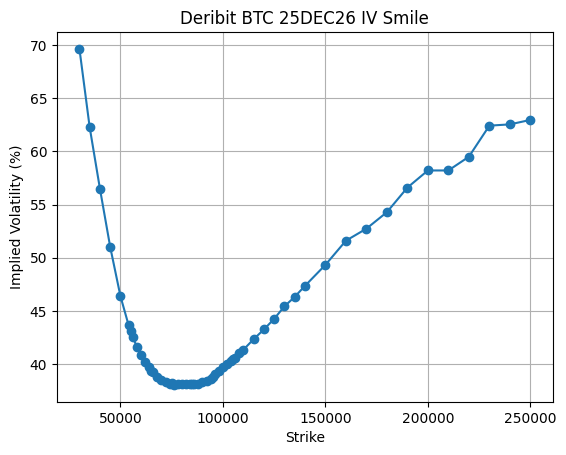

In [137]:
surface.plot_smile(options_df=dr.options_df, exchange="Deribit")

In [139]:
class OKX:
    def __init__(self, target_expiry):
         self.get_spot()
         self.get_df()
         self.get_smile(target_expiry)

    def get_spot(self):
        url = "https://www.okx.com/api/v5/market/ticker"
        params = {"instId": "BTC-USDT"}

        data = requests.get(url=url, params=params).json()["data"][0]

        self.spot = float(data["last"])
        self.volume = float(data["vol24h"])
        print("spot:", self.spot, "volume24h:", self.volume)

    def get_df(self):

        url = "https://www.okx.com/api/v5/public/instruments?instType=OPTION&uly=BTC-USD"
        data = requests.get(url).json()
        contract_size = float(data["data"][0]["ctVal"])
        
        url = "https://www.okx.com/api/v5/public/open-interest"
        params = {
            "instType": "OPTION",
            "uly": "BTC-USD"
        }

        oi = requests.get(url=url, params=params).json()["data"]
        oi_df = pd.DataFrame(oi)
        oi_df = oi_df.rename(columns={"oi": "open_interest"})
        oi_df["open_interest"] = oi_df["open_interest"].astype(float)
        oi_df["open_interest_notional"] = oi_df["open_interest"] * contract_size

        url = "https://www.okx.com/api/v5/public/opt-summary"
        params = {"uly": "BTC-USD"}

        summary = requests.get(url=url, params=params).json()["data"]
        summary_df = pd.DataFrame(summary)
        summary_df = summary_df.rename(columns={"markVol": "mark_iv"})
        summary_df["mark_iv"] = summary_df["mark_iv"].astype(float)

        parts = summary_df["instId"].str.split("-")

        summary_df["ccy"] = parts.str[1]
        summary_df["strike"] = parts.str[3].astype(float)
        summary_df["expiry"] = pd.to_datetime(parts.str[2], format="%y%m%d").dt.strftime("%Y%m%d")
        summary_df["option_type"] = parts.str[4].map({"C": "call", "P": "put"})

        self.okx_df = summary_df.merge(oi_df, on="instId", how="left")

    def get_smile(self, target_expiry):

        self.options_df = self.okx_df[
            (self.okx_df["ccy"] == "USD") &
            (self.okx_df["expiry"] == target_expiry) &
            (self.okx_df["option_type"] == "call") &
            (self.okx_df["open_interest_notional"] >= 10)
        ]

        self.options_df = self.options_df.sort_values("strike")

okx = OKX(target_expiry=target_expiry)
okx.options_df.head()

spot: 64044.0 volume24h: 6932.07938309


,askVol,bidVol,buyApr,delta,deltaBS,distance,fwdPx,gamma,gammaBS,instId,...,ccy,strike,expiry,option_type,instType_y,open_interest,oiCcy,oiUsd,ts_y,open_interest_notional
555,0.7592858251953125,0.6616297705078126,,0.43442536229333956,0.9767492461532504,-0.53914517,65096.420968447575994,-0.7480644900602128,0.0000018877037487452892,BTC-USD-261225-30000-C,...,USD,30000.0,20261225,call,OPTION,4075.0,40.75,2608741.65,1785927195897,4075.0
548,0.6665125732421876,0.6201259472656251,,0.49531158213231313,0.9631337337827035,-0.46233603,65096.420968447575994,-0.7881111652793189,0.0000031649522079165593,BTC-USD-261225-35000-C,...,USD,35000.0,20261225,call,OPTION,150.0,1.5,96027.3,1785927195897,150.0
532,0.523080242919922,0.4992765795898437,,0.584830521899577,0.9080518668361703,-0.30871776,65096.420968447575994,-0.6486326837235085,0.000008142874826534098,BTC-USD-261225-45000-C,...,USD,45000.0,20261225,call,OPTION,163.0,1.63,104349.666,1785927195897,163.0
529,0.47272633972167966,0.4586882818603516,,0.5991904330504889,0.8548572840511589,-0.23190862,65096.420968447575994,-0.4092360291075304,0.00001233312449001884,BTC-USD-261225-50000-C,...,USD,50000.0,20261225,call,OPTION,510.0,5.1,326492.82,1785927195897,510.0
556,0.45777275634765624,0.4422088226318359,,0.5965520678188984,0.8267098606254588,-0.20118496,65096.420968447575994,-0.2782999679770269,0.000014296987263748665,BTC-USD-261225-52000-C,...,USD,52000.0,20261225,call,OPTION,50.0,0.5,32009.1,1785927195897,50.0


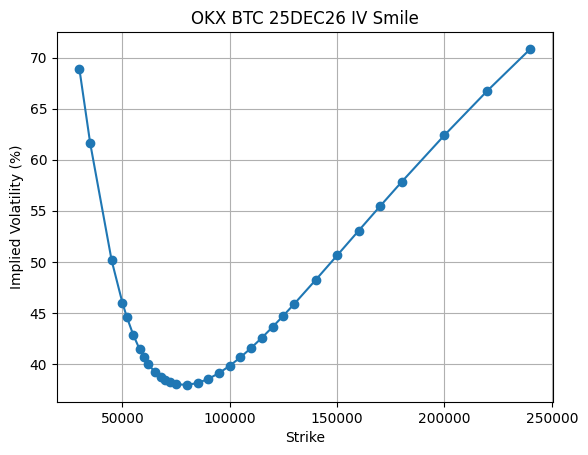

In [140]:
surface.plot_smile(options_df=okx.options_df, exchange="OKX")

In [141]:
class Bybit:
    def __init__(self, target_expiry):
         self.get_spot()
         self.get_df()
         self.get_smile(target_expiry)

    def get_spot(self):
        url = "https://api.bybit.com/v5/market/tickers"
        params = {
            "category": "spot",
            "symbol": "BTCUSDT"
        }

        data = requests.get(url=url, params=params).json()["result"]["list"][0]
        
        self.spot = float(data["lastPrice"])
        self.volume = float(data["volume24h"])
        print("spot:", self.spot, "volume24h:", self.volume)

    def get_df(self):
        contract_size = 1.0

        url = "https://api.bybit.com/v5/market/tickers"
        params = {
            "baseCoin": "BTC",
            "category": "option"
        }

        bybit_data = requests.get(url=url, params=params).json()["result"]["list"]
        bybit_df = pd.DataFrame(bybit_data)
        bybit_df = bybit_df.rename(columns={"markIv": "mark_iv", 
                                            "openInterest": "open_interest"})

        bybit_df["open_interest"] = bybit_df["open_interest"].astype(float)
        bybit_df["open_interest_notional"] = bybit_df["open_interest"] * contract_size
        bybit_df["mark_iv"] = bybit_df["mark_iv"].astype(float)

        parts = bybit_df["symbol"].str.split("-")
        bybit_df["expiry"] = pd.to_datetime(parts.str[1], format="%d%b%y").dt.strftime("%Y%m%d")
        bybit_df["strike"] = parts.str[2].astype(float)
        bybit_df["option_type"] = parts.str[3].map({"C": "call", "P": "put"})

        self.bybit_df = bybit_df

    def get_smile(self, target_expiry):

        self.options_df = self.bybit_df[
            (self.bybit_df["expiry"] == target_expiry) &
            (self.bybit_df["option_type"] == "call") &
            (self.bybit_df["open_interest_notional"] >= 10)
        ]

        self.options_df = self.options_df.sort_values("strike")

bybit = Bybit(target_expiry=target_expiry)
bybit.options_df.head()

spot: 64047.1 volume24h: 6553.598908


,symbol,bid1Price,bid1Size,bid1Iv,ask1Price,ask1Size,ask1Iv,lastPrice,highPrice24h,lowPrice24h,...,delta,gamma,vega,theta,predictedDeliveryPrice,change24h,open_interest_notional,expiry,strike,option_type
285,BTC-25DEC26-70000-C-USDT,4275,2.53,0.3826,4335,1,0.3864,4295,4380,4295,...,0.42868318,0.00002512,159.43254531,-21.6232676,0,0.02019003,20.73,20261225,70000.0,call
333,BTC-25DEC26-75000-C-USDT,2795,4.68,0.3791,2830,6.4,0.3816,2700,2700,2700,...,0.3169239,0.00002308,144.65223534,-19.37020935,0,0,14.95,20261225,75000.0,call
310,BTC-25DEC26-80000-C-USDT,1800,17.14,0.3787,1820,7.62,0.3803,1805,1830,1705,...,0.22641223,0.00001955,122.23993066,-16.33631266,0,0.07761195,33.64,20261225,80000.0,call
331,BTC-25DEC26-85000-C-USDT,1145,9.65,0.3794,1180,16.76,0.383,1150,1155,1090,...,0.1587609,0.00001563,98.3181192,-13.21976011,0,0.01321586,17.38,20261225,85000.0,call
276,BTC-25DEC26-90000-C-USDT,740,2.18,0.3832,775,22.18,0.3878,740,755,740,...,0.11071373,0.00001205,76.72471654,-10.43704494,0,0,18.48,20261225,90000.0,call


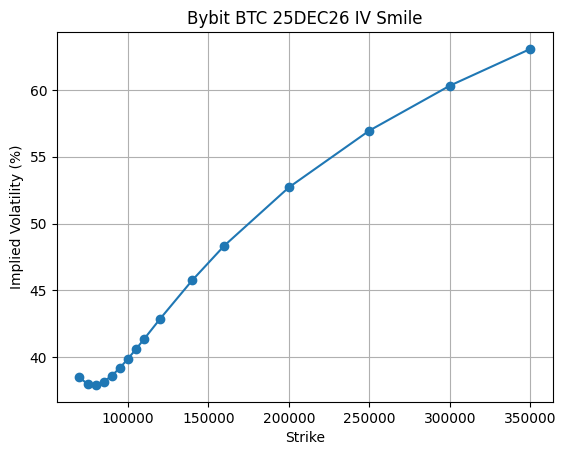

In [142]:
surface.plot_smile(options_df=bybit.options_df, exchange="Bybit")

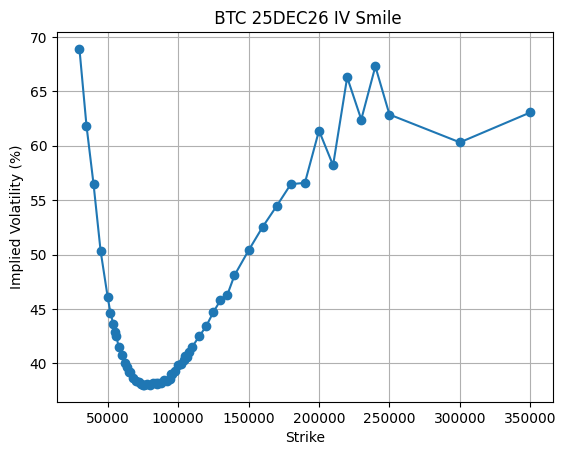

weighted spot: 64045.49993881119


In [152]:
surface.get_overall_smile(dr.options_df, okx.options_df, bybit.options_df)
surface.plot_smile(options_df=surface.curve, exchange="")
surface.get_weighted_spot(dr, okx, bybit)

In [153]:
today = datetime.now(timezone.utc)
T = (target_expiry_dt - today).total_seconds() / (365 * 24 * 60 * 60)

surface.interpolate_iv(surface.curve, required_strike)

surface.prob_touch(spot=surface.weighted_spot, 
                   strike=required_strike,
                   iv=surface.iv,
                   T=T,
                   r=0)

BTC 100000.0 strike iv: 0.39813540834727895
p_touch: 0.05401


In [ ]:
# Keep trading journal

# Your thesis.
# Why you think the market is mispriced.
# Position size.
# Exit criteria.
# What actually happened.

In [ ]:
class BTCOptionSurface:
    def __init__(self, target_expiry_str):
        self.target_expiry_str = target_expiry_str

    def find_closest_expiry(self, target_expiry):

        available = list(self.curves.keys())

        target = pd.to_datetime(
            target_expiry
        )

        closest_expiry = min(
            available,
            key=lambda x: abs(
                pd.to_datetime(x) - target
            )
        )

        return closest_expiry

    def get_overall_smile(self, dr_options_df, okx_options_df, bybit_options_df):
        all_options = pd.concat([dr_options_df, okx_options_df, bybit_options_df], ignore_index=True)

        curve = all_options.groupby("strike").apply(
            lambda x: np.average(x.mark_iv, weights=x.open_interest_notional)).reset_index()

        curve.columns = ["strike", "mark_iv"]

        self.curve = curve

    def get_surface(self, dr_df, okx_df, bybit_df):
        all_options = pd.concat([dr_df, okx_df, bybit_df], ignore_index=True)

        surface = all_options.groupby(["strike", "T"]).apply( #call and put same surface, pc parity
            lambda x: np.average(x.total_variance, weights=x.open_interest_notional)).reset_index()

        surface.columns = ["strike", "T", "total_variance"]

        self.surface = surface

    def get_weighted_spot(self, dr, bybit, okx):
        spots = [dr.spot, bybit.spot, okx.spot]
        weights = [dr.volume, bybit.volume, okx.volume]

        self.weighted_spot = np.average(spots, weights=weights)

        print("weighted spot:", self.weighted_spot)

    def plot_smile(self, options_df, exchange):

        plt.plot(options_df.strike,
                options_df.mark_iv * 100,   # convert decimal IV to %
                marker="o"
            )
        
        plt.xlabel("Strike")
        plt.ylabel("Implied Volatility (%)")
        plt.title(f"{exchange} BTC {self.target_expiry_str} IV Smile")
        plt.grid(True)

        plt.show()

    def build_variance_surface(self, surface):

        points = np.column_stack(
            [
                surface["strike"],
                surface["T"]
            ]
        )

        values = surface["total_variance"]

        variance_surface = LinearNDInterpolator(
            points,
            values
        )

        return variance_surface

        # variance_surface = surface( use case
        #     #strike,
        #     #T
        # )

    def plot_surface(self, surface, variance_surface):

        # surface.plot_surface( use case
        #     call_options,
        #     call_surface
        # )

        from mpl_toolkits.mplot3d import Axes3D

        fig = plt.figure(figsize=(10, 7))

        ax = fig.add_subplot(
            111,
            projection="3d"
        )

        # Create grid
        strike_grid = np.linspace(
            surface["strike"].min(),
            surface["strike"].max(),
            50
        )

        T_grid = np.linspace(
            surface["T"].min(),
            surface["T"].max(),
            50
        )


        X, Y = np.meshgrid(
            strike_grid,
            T_grid
        )


        # Query interpolator
        variance_grid = variance_surface(
            X,
            Y
        )


        # Convert variance back to IV
        IV_grid = np.sqrt(
            variance_grid / Y
        )


        # Plot surface
        ax.plot_surface(
            X,
            Y,
            IV_grid,
            cmap="viridis",
            alpha=0.8
        )


        # Plot original points
        ax.scatter(
            surface["strike"],
            surface["T"],
            surface["mark_iv"],
            color="red",
            s=20
        )


        ax.set_xlabel("Strike")
        ax.set_ylabel("Time to Expiry (years)")
        ax.set_zlabel("Implied Volatility")


        plt.show()

    def interpolate_iv(self, options_df, required_strike):
        # Question: Will BTC hit 100000 by 31DEC26?

        # It prevents wild overshoots and spurious oscillations found in standard cubic splines, 
        # making it ideal for monotonic data, bounded physical measurements, and financial curves
        f = PchipInterpolator(options_df.strike, options_df.mark_iv)

        self.iv = float(f(required_strike))

        print(f"BTC {required_strike} strike iv: {self.iv}")

    def prob_finish_above(self, spot, strike, iv, T, r=0):

        d2 = (np.log(spot / strike) + (r - 0.5 * iv ** 2) * T) / (iv * np.sqrt(T))

        self.p_finish_above = norm.cdf(d2)

        print("p_finish_above:", self.p_finish_above)

    def prob_touch(self, spot, strike, iv, T, r=0, paths=100000, time_steps=365):

        # dS = rSdt + σSdW
        dt = T / time_steps
        Z = np.random.normal(0, 1, size=(paths, time_steps)) # vectorization

        daily_return = ((r - 0.5 * iv ** 2) * dt + iv * np.sqrt(dt) * Z)

        prices = spot * np.exp(np.cumsum(daily_return, axis=1))

        hit = prices.max(axis=1) >= strike

        self.p_touch = hit.mean()

        print("p_touch:", self.p_touch)

surface = BTCOptionSurface(target_expiry_str)